In [4]:
import pandas as pd

In [5]:
movies = pd.read_csv(r'F:\GenAI&AgeAI\Notes\Dec\23Dec - Kaggle & Pandas\movie.csv')
print(movies.shape)
print(type(movies))
movies.head(5)

(27278, 3)
<class 'pandas.core.frame.DataFrame'>


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
movies.columns

Index(['movieId', 'title', 'genres'], dtype='object')

In [6]:
ratings = pd.read_csv(r'F:\GenAI&AgeAI\Notes\Dec\23Dec - Kaggle & Pandas\rating.csv')
print(ratings.shape)
print(type(ratings))
ratings.head(5)

(20000263, 4)
<class 'pandas.core.frame.DataFrame'>


,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


In [8]:
ratings.columns

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')

In [7]:
tags = pd.read_csv(r'F:\GenAI&AgeAI\Notes\Dec\23Dec - Kaggle & Pandas\tag.csv', sep=',', parse_dates=['timestamp'])
print(tags.shape)
print(type(tags))
tags.head(5)

(465564, 4)
<class 'pandas.core.frame.DataFrame'>


,userId,movieId,tag,timestamp
0,18,4141,Mark Waters,2009-04-24 18:19:40
1,65,208,dark hero,2013-05-10 01:41:18
2,65,353,dark hero,2013-05-10 01:41:19
3,65,521,noir thriller,2013-05-10 01:39:43
4,65,592,dark hero,2013-05-10 01:41:18


Remove timestamp

In [8]:
del ratings['timestamp']
del tags['timestamp']

# Data Structures

Series

In [17]:
row_0 = tags.iloc[0]
print(type(row_0))
print(row_0)

<class 'pandas.core.series.Series'>
userId              18
movieId           4141
tag        Mark Waters
Name: 0, dtype: object


In [22]:
print(row_0.index)

Index(['userId', 'movieId', 'tag'], dtype='object')


In [20]:
print(row_0['userId'])

18


In [23]:
'rating' in row_0

False

In [24]:
row_0.name

0

In [25]:
row_0 = row_0.rename('firstRow')
row_0.name

'firstRow'

DataFrames

In [26]:
tags.head()

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero


In [27]:
tags.index

RangeIndex(start=0, stop=465564, step=1)

In [28]:
tags.columns

Index(['userId', 'movieId', 'tag'], dtype='object')

In [29]:
tags.iloc[ [0,11,500] ]

,userId,movieId,tag
0,18,4141,Mark Waters
11,65,1783,noir thriller
500,342,55908,entirely dialogue


# Descriptive Statistics

In [31]:
ratings.head()

,userId,movieId,rating
0,1,2,3.5
1,1,29,3.5
2,1,32,3.5
3,1,47,3.5
4,1,50,3.5


In [32]:
ratings.describe()

,userId,movieId,rating
count,2.000026e+07,2.000026e+07,2.000026e+07
mean,6.904587e+04,9.041567e+03,3.525529e+00
std,4.003863e+04,1.978948e+04,1.051989e+00
min,1.000000e+00,1.000000e+00,5.000000e-01
25%,3.439500e+04,9.020000e+02,3.000000e+00
50%,6.914100e+04,2.167000e+03,3.500000e+00
75%,1.036370e+05,4.770000e+03,4.000000e+00
max,1.384930e+05,1.312620e+05,5.000000e+00


In [30]:
ratings['rating'].describe()

count    2.000026e+07
mean     3.525529e+00
std      1.051989e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

In [34]:
print(ratings['rating'].mean())

3.5255285642993797


In [35]:
ratings.mean()

userId     69045.872583
movieId     9041.567330
rating         3.525529
dtype: float64

In [36]:
ratings['rating'].min()

0.5

In [37]:
ratings['rating'].max()

5.0

In [38]:
ratings['rating'].std()

1.051988919275684

In [39]:
ratings['rating'].mode()

0    4.0
Name: rating, dtype: float64

In [40]:
ratings.corr()

,userId,movieId,rating
userId,1.000000,-0.000850,0.001175
movieId,-0.000850,1.000000,0.002606
rating,0.001175,0.002606,1.000000


In [41]:
filter1 = ratings['rating'] > 10
print(filter1)
filter1.any()

0           False
1           False
2           False
3           False
4           False
            ...  
20000258    False
20000259    False
20000260    False
20000261    False
20000262    False
Name: rating, Length: 20000263, dtype: bool


np.False_

In [42]:
filter2 = ratings['rating'] > 0
filter2.all()

np.True_

In [43]:
movies.isnull().any().any()

np.False_

In [44]:
ratings.isnull().any().any()

np.False_

In [52]:
tags.shape

(465564, 3)

In [45]:
tags.isnull().any().any()

np.True_

In [46]:
tags=tags.dropna()

In [47]:
tags.isnull().any().any()

np.False_

In [48]:
tags.shape

(465548, 3)

Thats nice ! No NULL values ! Notice the number of lines have reduced.

# Data Visualization

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = 10,5

import warnings
warnings.filterwarnings('ignore')

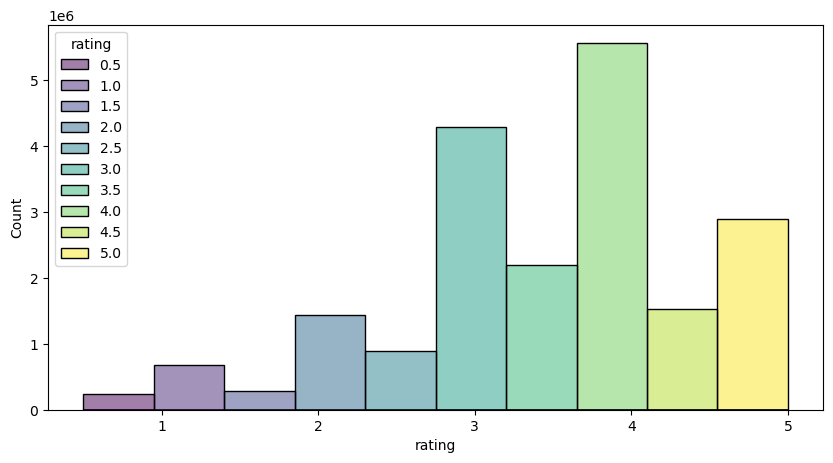

In [19]:


vis = sns.histplot(data=ratings, x='rating', kde=True, hue='rating',bins=10, palette='viridis', legend=True)
plt.show()

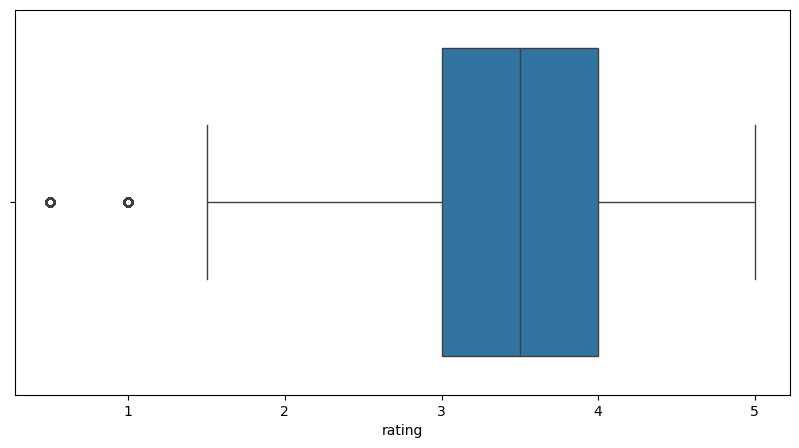

In [23]:
vis = sns.boxplot(data=ratings, x='rating')
plt.show()

# Slicing Out Columns

In [24]:
tags['tag'].head()

0      Mark Waters
1        dark hero
2        dark hero
3    noir thriller
4        dark hero
Name: tag, dtype: object

In [28]:
movies.columns

Index(['movieId', 'title', 'genres'], dtype='object')

In [29]:
movies[['title','genres']].head()

,title,genres
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,Jumanji (1995),Adventure|Children|Fantasy
2,Grumpier Old Men (1995),Comedy|Romance
3,Waiting to Exhale (1995),Comedy|Drama|Romance
4,Father of the Bride Part II (1995),Comedy


In [31]:
ratings[-10:] 

,userId,movieId,rating
20000253,138493,60816,4.5
20000254,138493,61160,4.0
20000255,138493,65682,4.5
20000256,138493,66762,4.5
20000257,138493,68319,4.5
20000258,138493,68954,4.5
20000259,138493,69526,4.5
20000260,138493,69644,3.0
20000261,138493,70286,5.0
20000262,138493,71619,2.5


In [33]:
tag_count = tags['tag'].value_counts()
tag_count[10:]

tag
stylized               1941
quirky                 1906
dark comedy            1899
classic                1769
psychology             1754
                       ... 
Diamond Dallas Page       1
I'm Devon Butler!         1
No arguement              1
Really Bad                1
Botox                     1
Name: count, Length: 38633, dtype: int64

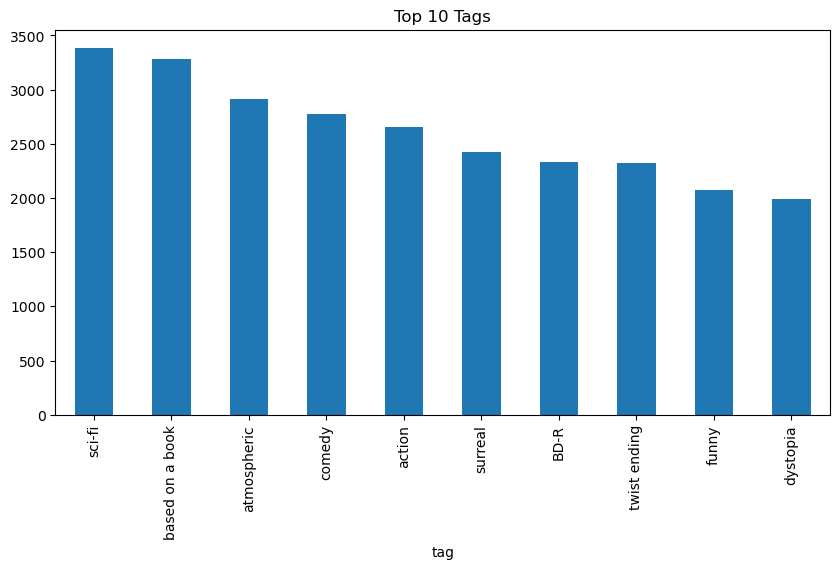

In [36]:
tag_count[:10].plot(kind='bar', figsize=(10,5), title='Top 10 Tags')
plt.show()

# Filters for Selecting Rows

In [40]:
is_highly_rated  = ratings['rating'] >= 5.0
ratings[is_highly_rated][30:35]

,userId,movieId,rating
239,3,50,5.0
242,3,175,5.0
244,3,223,5.0
245,3,260,5.0
246,3,316,5.0


In [41]:
is_action_genre = movies['genres'].str.contains('Action')
movies[is_action_genre][30:35]

,movieId,title,genres
171,173,Judge Dredd (1995),Action|Crime|Sci-Fi
179,181,Mighty Morphin Power Rangers: The Movie (1995),Action|Children
183,185,"Net, The (1995)",Action|Crime|Thriller
196,198,Strange Days (1995),Action|Crime|Drama|Mystery|Sci-Fi|Thriller
202,204,Under Siege 2: Dark Territory (1995),Action


In [42]:
movies[is_action_genre].head(3)

,movieId,title,genres
5,6,Heat (1995),Action|Crime|Thriller
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


# Group By and Aggregate

In [45]:
ratings.columns

Index(['userId', 'movieId', 'rating'], dtype='object')

In [48]:
ratings_count = ratings[['movieId','rating']].groupby('rating').count()
ratings_count

,movieId
rating,
0.5,239125
1.0,680732
1.5,279252
2.0,1430997
2.5,883398
3.0,4291193
3.5,2200156
4.0,5561926
4.5,1534824


In [49]:
average_rating = ratings[['movieId','rating']].groupby('movieId').mean()    
average_rating.head()

,rating
movieId,
1,3.921240
2,3.211977
3,3.151040
4,2.861393
5,3.064592


In [50]:
movie_count = ratings[['movieId','rating']].groupby('movieId').count()
movie_count.head()

,rating
movieId,
1,49695
2,22243
3,12735
4,2756
5,12161


In [51]:
movie_count.tail()

,rating
movieId,
131254,1
131256,1
131258,1
131260,1
131262,1
